## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

---

# PRÁCTICA No. 25: CNN(Mnist)

### La CNN se implementara para predecir imagenes de la base de datos Mnist (10 numeros escritos a mano) 
### La base de datos es un conjunto de datos muy utilziado en el aprendizaje automatico y la vision por computadora. Contene imagenes de digitos escritos a mano del 0 al 9, con las siguienes caracteristicas: 70,000 imagenes en total 60,000 para entrenamiento y 10,000 para prueba, imagenes en escala de grises de 28x28 pixeles, y etiquetadas con el  numero correspondiente




## Paso 1: Importar las librerías necesarias

In [2]:
import os 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense,Dropout,Flatten, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import LeakyReLU

## Paso 2. Cargamos el dataset

In [3]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.datasets import mnist

#cargar dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

#ejemplo de imagen
pd.DataFrame(X_train[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 177s 15us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,...,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,...,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,...,0,0,0,0,0,0,0,0,0,0


## Paso 3: Graficamos las imagenes de los digitos

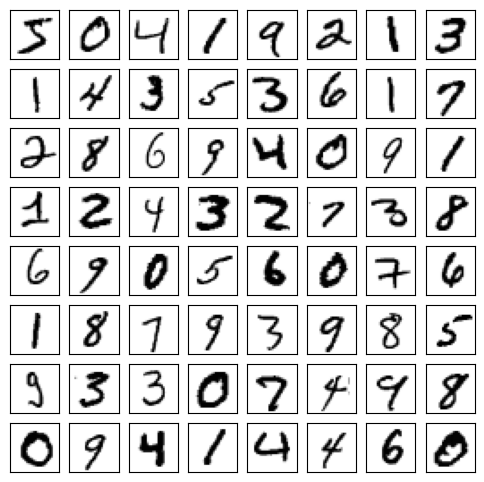

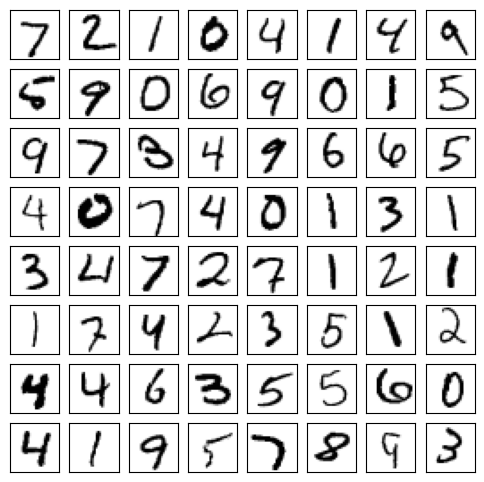

In [4]:
fig, ax = plt.subplots(8, 8, figsize=(6, 6), dpi=100)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_train[i], cmap='binary', vmin=0, vmax=255 )
    axi.set(xticks=[], yticks=[])
    
fig, ax = plt.subplots(8, 8, figsize=(6, 6), dpi=100)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i], cmap='binary', vmin=0, vmax=255 )
    axi.set(xticks=[], yticks=[])
    
    

### Paso 4: Transformacion de datos

In [5]:

#Calculamos la cantidad de etiquetas
num_labels= len(np.unique(y_train))
print( "Numero de etiquetas: ",num_labels)

#Convertimos las etiquetas a formato one-hot
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print(y_train[0:8], "\n")

#Dimensiones de entrada de la imagen
image_size = X_train.shape[1]
print("Tamaño de la imagen: ", image_size)

#Redimensionamos las imagenes para que sean compatibles con la entrada de la red
X_train=np.reshape(X_train, [-1,image_size, image_size, 1])
X_test=np.reshape(X_test, [-1,image_size, image_size, 1])
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

print("Dimensiones de X_train: ", X_train.shape)
print("Dimensiones de X_test: ", X_test.shape)





Numero de etiquetas:  10
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]] 

Tamaño de la imagen:  28
Dimensiones de X_train:  (60000, 28, 28, 1)
Dimensiones de X_test:  (10000, 28, 28, 1)


### Paso 5: Construimos la estructura de la red CNN


In [6]:
#La imgenes es procesada en escala de grises, por lo que el canal de color es 1

import matplotlib.pyplot as plt
input_shape = (image_size, image_size, 1)
kernel_size = 3 
pool_size = 2
dropout = 0.2
filters = 64

model=keras.Sequential()
model.add(Conv2D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=pool_size))

model.add(Conv2D(filters=filters, kernel_size=kernel_size, activation='relu'))
model.add(MaxPooling2D(pool_size=pool_size))

model.add(Conv2D(filters=filters, kernel_size=kernel_size, activation='relu'))

#Aplanamos los datos para que puedan ser procesados por la capa densa
model.add(Flatten())

#Dropout para evitar el sobreajuste
model.add(Dropout(dropout))

#Capas ocultas
model.add(Dense(40, activation='relu'))
model.add(Dense(20, activation='sigmoid'))

#Capa de salida debe de ser 10-dim one-hot-vector
model.add(Dense(num_labels))
model.add(Activation('softmax'))

#Resumen del modelo
model.summary()

c:\Users\Laremo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │        23,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,606 (385.18 KB)

 Trainable params: 98,606 (385.18 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 6: configuramos el modelo

In [7]:
# Funcion de costo para hot-one-hot-vector
model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

## Entrenamiento y evaluación

In [8]:
batch_size= 128
model.fit(X_train, y_train, batch_size=batch_size, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.8718 - loss: 0.7180
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9776 - loss: 0.1510
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9841 - loss: 0.0836
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9873 - loss: 0.0593
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9896 - loss: 0.0465
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9915 - loss: 0.0363
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9922 - loss: 0.0311
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9936 - loss: 0.0254
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9941 - loss: 0.0235
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9946 - loss: 0.0196


In [9]:
salida, acc = model.evaluate(X_test, y_test,  batch_size=batch_size, verbose=0)
print("Precision global: %.2f%%" % (acc*100))

Precision global: 98.99%


## Paso 8: Ejemplo de predicción de Imágenes

(10000, 28, 28, 1)
[7 2 1 ... 4 5 6]


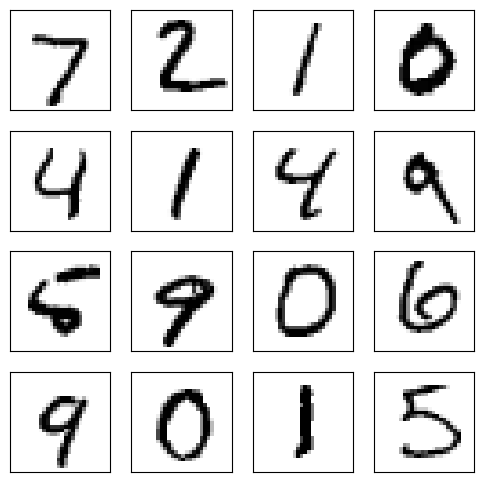

In [10]:
# Carfa el mnist dataset
train, (X_test, y_test) = mnist.load_data()

# estos datos osn los que puede procesar el modelo
X_test_model = np.reshape(X_test, [-1, 28, 28, 1])
X_test_model = X_test_model.astype('float32') / 255

print(X_test_model.shape)
print(y_test)

# Graficamos los números que vamos a intentar clasificar
fig, ax = plt.subplots(4, 4, figsize=(6, 6), dpi=100)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i], cmap='binary', vmin=0, vmax=255 )
    axi.set(xticks=[], yticks=[])



## Paso 9: no se

In [12]:
pred = model.predict(X_test_model[0:16])
print("Predicciones de salida: ", pred)
pred[0: 16]

# para obtener las etiquetas 
pred = np.argmax(pred, axis=1)
# MOstramos las predicciones
print("Predicciones de salida: ", pred)
print("Prdicciones en 4x4", np.reshape(pred, (4, 4)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicciones de salida:  [[9.71098416e-05 1.44527599e-04 3.78426455e-04 7.01694153e-05
  2.54321407e-04 1.29510969e-04 1.83754207e-06 9.98251617e-01
  9.41245162e-05 5.78199164e-04]
 [6.98486765e-05 6.99119846e-05 9.98770654e-01 3.38781218e-04
  1.69420746e-04 3.38345944e-06 2.19074922e-04 2.42752983e-04
  2.92052537e-05 8.69801661e-05]
 [3.48968606e-05 9.98510778e-01 5.53521677e-05 3.08624498e-04
  1.83554424e-04 1.84337521e-04 1.91145718e-05 3.37714533e-04
  2.98560539e-04 6.69975925e-05]
 [9.97289658e-01 3.96388823e-05 4.85337456e-04 4.04490303e-04
  1.65328747e-04 3.00958141e-04 2.57034524e-04 4.05091560e-04
  8.33270678e-05 5.69202472e-04]
 [2.86213799e-05 1.71428677e-04 1.53611574e-04 2.44626950e-04
  9.98797774e-01 1.62053839e-05 1.20176883e-04 1.45316022e-04
  1.15403593e-04 2.06843601e-04]
 [3.78586628e-05 9.98479426e-01 5.84357294e-05 3.00634303e-04
  1.78954084e-04 1.83575961e-04 1.79002272e-05 3.69442190e-04
  3.00811836e-04 7.29477615e

## Conclusiones

En esta práctica implementamos una red neuronal convolucional (CNN) utilizando Keras y TensodFlow. La red neuronal se implemento apra reconocer lar imágenese d enúmeros hechos a mano de la base e datos que está incluida en python llamada mnist.


## Referencias 

### Pillow (PIL) Documentation:
### Pillow Core Team. (2024). ImageFilter Module - Kernel Class. Recuperado de https://pillow.readthedocs.io/en/stable/reference/ImageFilter.html

### Fundamentos de Procesamiento de Imágenes:
Gonzalez, R. C., & Woods, R. E. (2018). Digital Image Processing (4th ed.). Pearson.

### Algoritmos de Detección de Bordes:
Sobel, I. (2014). An Isotropic 3x3 Image Gradient Operator. Presentation at Stanford Artificial Intelligence Project.

### Relación con Computación e Interfaces:
Szeliski, R. (2022). Computer Vision: Algorithms and Applications (2nd ed.). Springer Nature.